In [1]:
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "DDOS_O.csv"
)

df["Label"] = (
    df["Label"]
    .astype(str)
    .str.strip()
    .map({
        "BENIGN": 0,
        "DDoS": 1
    })
)

In [4]:
X = df.drop("Label", axis=1)

y = df["Label"]

In [6]:
xgb = joblib.load(
    "xgboost_model.pkl"
)

print("Model Loaded")

Model Loaded


In [7]:
explainer = shap.TreeExplainer(xgb)

print("Explainer Ready")

Explainer Ready


In [8]:
X_sample = X.sample(
    1000,
    random_state=42
)

In [9]:
shap_values = explainer.shap_values(
    X_sample
)

print("SHAP Values Generated")

SHAP Values Generated


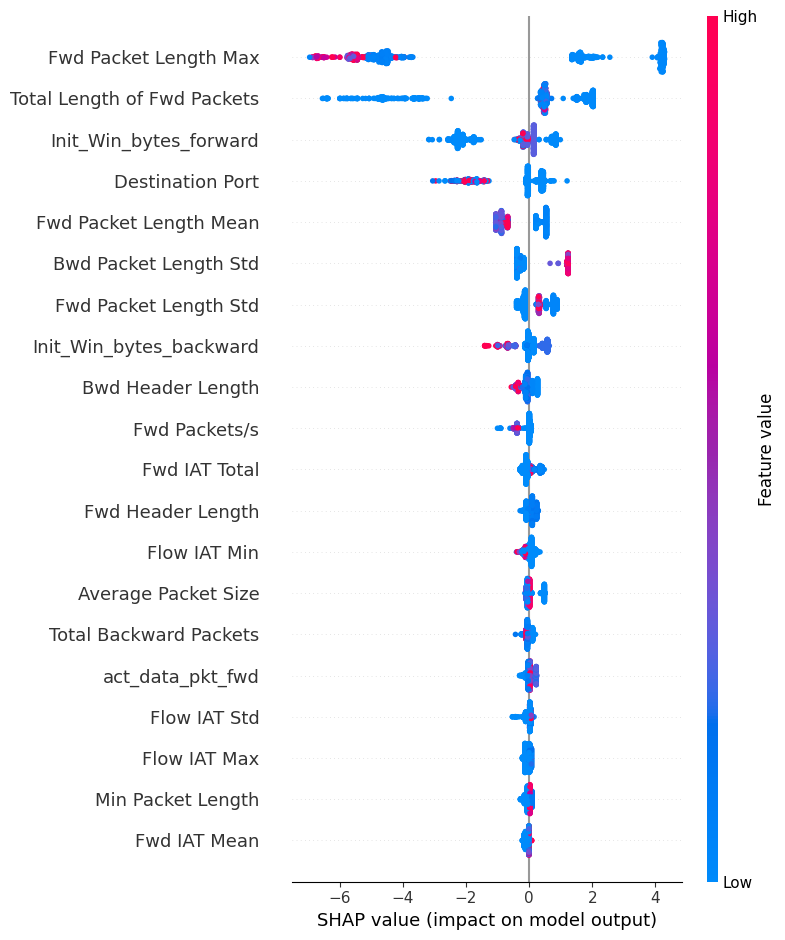

In [10]:
shap.summary_plot(
    shap_values,
    X_sample
)

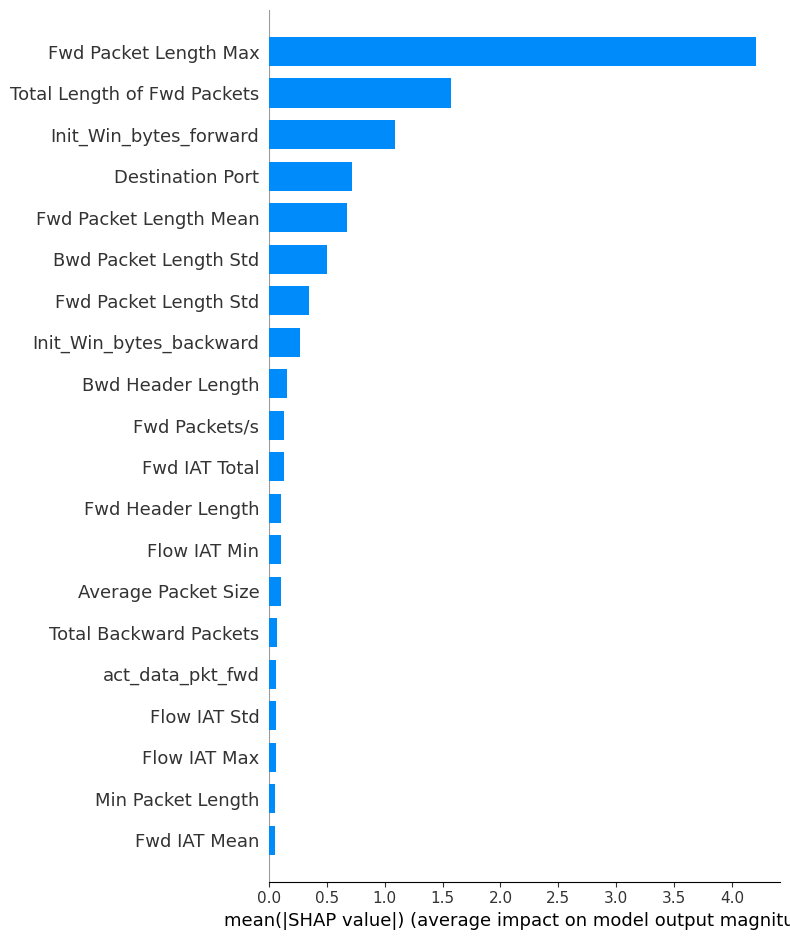

In [11]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

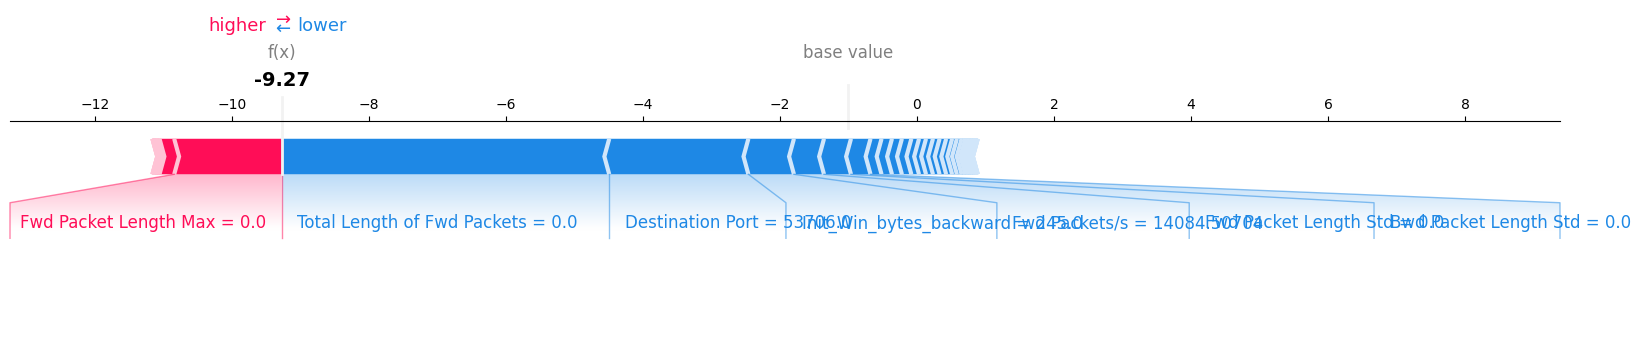

In [13]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    matplotlib=True
)

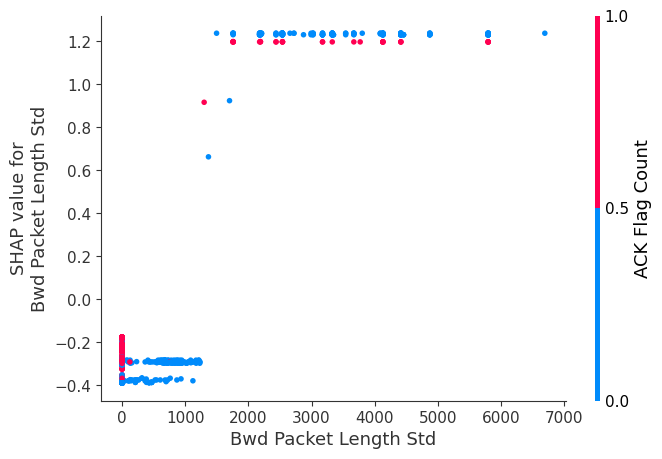

In [14]:
shap.dependence_plot(
    "Bwd Packet Length Std",
    shap_values,
    X_sample
)